# Color Quantization

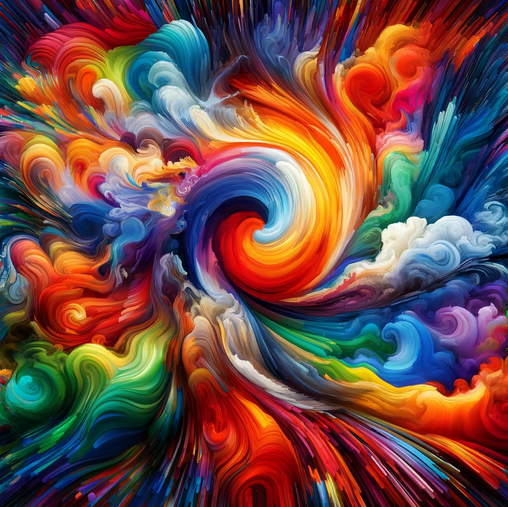

## Introduction
A standard color image of dimensions $n \times m$ is represented by $n \cdot m \cdot 3$ integers in the range $[0, 255]$. This yields a total of over 16 million possible colors. Color quantization involves drastically reducing the number of used colors to reduce file size while preserving image quality as best as possible.
The simplest method of quantization is the $k$-means clustering. It works excellently for color reduction, but its nature also affects the final appearance of the image:

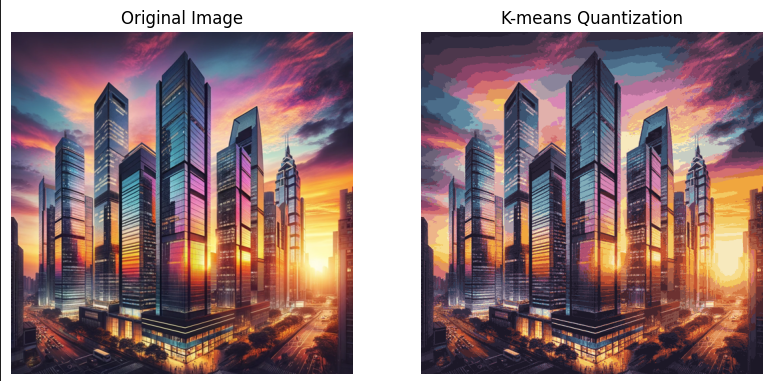

The ([$k$-means](https://en.wikipedia.org/wiki/K-means_clustering)) method quantizes the image by minimizing the mean squared error ([MSE](https://en.wikipedia.org/wiki/Mean_squared_error)) between the original and the reconstructed image. 
However, it completely ignores *which* colors it ultimately uses. It turns out that if we impose penalties (costs) for using certain colors, we can influence the quality of quantization. In that case, however, the standard $k$-means method will no longer be optimal.

Changing the quantization method can thus affect the final quality of the quantized image. And this is exactly what the task below is about.

## Task

The goal of the task is to write a clustering algorithm that minimizes an objective function different from $k$-means.
First, let's define the *color cost*. We understand an RGB color as a three-dimensional vector from the set $[0,1,...,255]^3$, and the cost of color $c$ is defined as the Euclidean distance to the nearest "simple" color in the RGB space, where we consider the following as simple colors: black $(0,0,0)$, white $(255,255,255)$, red $(255,0,0)$, green $(0,255,0)$, blue $(0,0,255)$, yellow $(255,255,0)$, magenta $(255,0,255)$, and cyan $(0,255,255)$. Details can be found in the `color_cost` function.
With this cost function defined, the most expensive color is $(127,127,127)$, i.e., gray. 
The interpretation of this cost function is that we want to force the quantization algorithm to prefer colors that are more vibrant and vivid.

Our objective function will be a weighted sum of individual components:
1. `MSE`: the mean squared error between the original and reconstructed image — this component ensures the quantized image is close to the original.
2. `max_color_cost`: the highest cost among the used colors — this component enhances color vibrancy by controlling the least vibrant color.
3. `mean_color_cost`: the average color cost calculated over all pixels — this component forces the used colors to be sufficiently vibrant on average.

The final criterion for quantization quality will be:
$$2\cdot MSE  + 21\cdot max\_color\_cost + 42\cdot mean\_color\_cost$$

The above criterion and all functions mentioned above are implemented by us below. 

In this task, we assume that the number of colors is fixed in advance and equals $37$. Your algorithm must therefore quantize the image into $37$ colors in such a way as to minimize the above objective function.

## Constraints
- You may use a GPU for this task.
- Your function should return 5 quantized images in a maximum of 3 minutes using Google Colab with GPU.
- Both the original and quantized images should be provided to the evaluation function as `np.array` of type `np.uint8` with values in the range $[0, 255]$.

## Notes and Tips
- Each image is an individual training set; during evaluation, no weights of models trained by you will be loaded.
- You will be working on images generated by DALL-E and Stable Diffusion.
- In the `your_quantization_algorithm` function, you must set a seed so that the results obtained on the training and validation sets transfer to the test set.

## Submission Files
Only this notebook.

## Evaluation
Remember that during testing, the `FINAL_EVALUATION_MODE` flag will be set to `True`. Using the `evaluation_script.py` script, you can ensure your solution will be correctly executed on our grading servers. 

You can score between 0 and 1.5 points for this task. If you get a score above 8900, you will receive 0 points, and if below 8000, you will receive 1.5 points. Between these values, your score decreases linearly with the score value.

# Starter Code

In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False
# During the evaluation of your solution, we will change this value to True
# The value of this flag M U S T be set to False in the solution you submit!

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################
import os
import numpy as np
from PIL import Image
import matplotlib.subplots as plt
import matplotlib.pyplot as plt
import typing

import glob

## Data Loading

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

# A class that facilitates loading images from a given folder
class ImageDataset:
    def __init__(self, image_dir: str):
        self.filelist = glob.glob(image_dir + "/*.jpg")
        self.IMAGE_DIMS = (512, 512)

    def __len__(self):
        return len(self.filelist)

    def __getitem__(self, idx) -> np.ndarray:
        with Image.open(self.filelist[idx]) as image:
            image = image.convert('RGB')
            image = image.resize(self.IMAGE_DIMS)
            return np.array(image)

    def __iter__(self) -> typing.Iterator[np.ndarray]:
        return (self[i] for i in range(len(self.filelist)))

## Code with evaluation criteria

In [ ]:
######################### DO NOT MODIFY THIS CELL ##########################

# Below you will find the definitions of MSE and the color usage cost
# Remember to calculate them in the RGB space during evaluation, i.e., on integer values from the range [0, 255]
# Scaling is only permitted during training!

# Let's define the quantization quality criterion
# We will use the mean squared error (MSE) for this
def mse(img, img_quant):
  return ((img_quant.astype(np.float32) - img.astype(np.float32))**2).mean()


# Next, let's define the color usage cost
# The closer a given color is to the "simple" colors, the lower its usage cost
def color_cost(img_quant):
    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    
    pixels = img_quant.reshape(-1,3)
    
    differences = pixels[:, np.newaxis, :] - vertices[np.newaxis, :, :]
    squared_distances = np.sum(differences**2, axis=2)
    costs = np.sqrt(np.min(squared_distances, axis=1))

    return np.mean(costs), np.max(costs)


# Total criterion defined in the task description
def quantization_score(img, img_quant):
    assert img.dtype == np.uint8
    assert img_quant.dtype == np.uint8
    assert len(np.unique(img_quant.reshape(-1,3), axis=0)) == 37
       
    mse_cost = mse(img, img_quant)
    mean_color_cost, max_color_cost = color_cost(img_quant)
    score = mse_cost * 2 + max_color_cost * 21 + mean_color_cost * 42
    print(f'MSE: {mse_cost:.4f}, max_color_cost: {max_color_cost:.4f}, mean_color_cost: {mean_color_cost:.4f}')
    print(f'Score: {score:.4f}')
    return score

# Your Solution

This section is the place for your solution. You should only make changes here!

In [ ]:
def dist(x, y):
    result = (x - y)**2
    result = np.sum(result)
    return np.sqrt(result)

def your_quantization_algorithm(img):
    from sklearn.cluster import KMeans

    pixels = img.reshape(-1, 3)
    
    # Initialize basic clustering
    kmeans = KMeans(n_clusters=37, random_state=0).fit(pixels)
    colors = kmeans.cluster_centers_
    labels = kmeans.predict(pixels)

    # Heuristically pull colors towards the nearest "simple" RGB vertices 
    # to minimize the custom objective function involving color cost
    for i in range(37):
        nearest = np.array(colors[i])
        for j in range(3):
            if nearest[j] > 127:
                nearest[j] = 255
            else:
                nearest[j] = 0
                
        d = dist(colors[i], nearest)
        LIMIT = 100
        
        # If the cluster center is too "gray" (far from vertices), pull it closer
        if d > LIMIT:
            alpha = 1 - LIMIT / d
            colors[i] = (1 - alpha) * colors[i] + alpha * nearest

    quantized_image = colors[labels].reshape(img.shape)
    quantized_image = quantized_image.astype(np.uint8)

    vertices = np.array([
        [0, 0, 0], [0, 0, 255], [0, 255, 0], [0, 255, 255],
        [255, 0, 0], [255, 0, 255], [255, 255, 0], [255, 255, 255]
    ])
    
    quantized_image = quantized_image.reshape(-1, 3)
    
    # Ensure exactly 37 unique colors exist in the final output to pass assertions
    idx = 0
    while len(np.unique(quantized_image, axis=0)) < 37:
        quantized_image[idx] = vertices[idx]
        idx += 1

    return quantized_image.reshape(img.shape)

# Evaluation

The following code will be used to evaluate the solution. After submitting the solution to us, the evaluate_algorithm(your_quantization_algorithm, 'test_data') function will be executed. Almost identical code as below will run on the test_data directory available only to the graders.

Ensure before submitting that the entire notebook executes from start to finish without errors and without user intervention after executing the Run All command.

In [ ]:
# Display a comparison of the original and quantized image
def show_quantization_results(original, quantized):
        _, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(original)
        ax[0].set_title("Original")
        ax[0].axis("off")

        ax[1].imshow(quantized)
        ax[1].set_title("Quantization result")
        ax[1].axis("off")
        plt.show()

In [ ]:
def evaluate_algorithm(quantization_algorithm, data_dir):
    dataset = ImageDataset(data_dir)
    scores = []
    for image in dataset:
        quantized_image = quantization_algorithm(image)
        show_quantization_results(image, quantized_image)
        score = quantization_score(image, quantized_image)
        scores.append(score)
    return np.mean(scores)

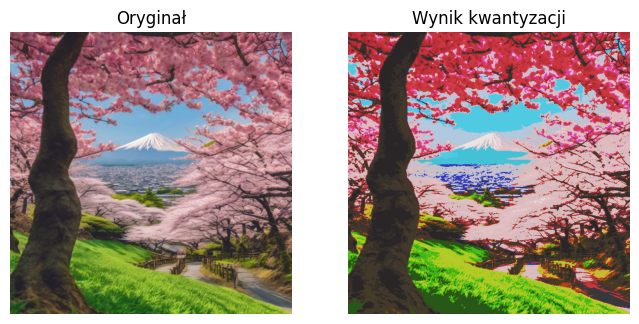

MSE: 1069.7682, max_color_cost: 101.2028, mean_color_cost: 95.8369
Score: 8289.9444


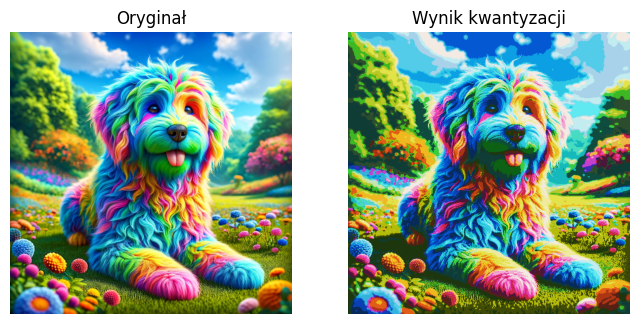

MSE: 676.7881, max_color_cost: 101.2571, mean_color_cost: 92.5869
Score: 7368.6262


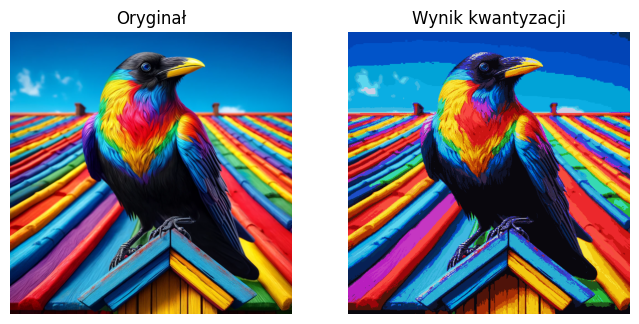

MSE: 481.4336, max_color_cost: 101.1583, mean_color_cost: 82.9731
Score: 6572.0621


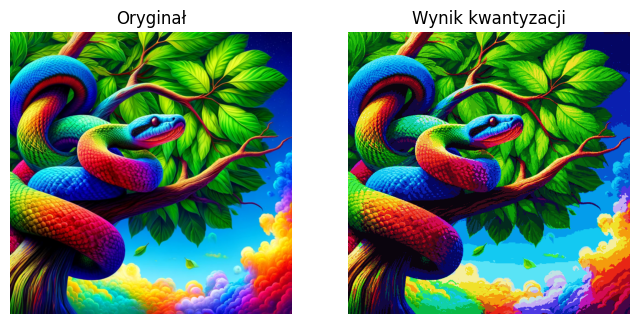

MSE: 377.1797, max_color_cost: 101.1533, mean_color_cost: 82.5774
Score: 6346.8320


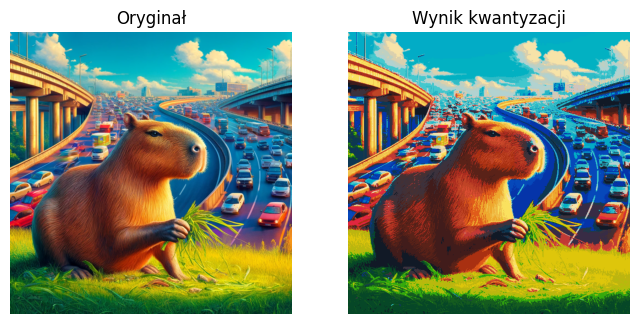

MSE: 641.4134, max_color_cost: 100.8117, mean_color_cost: 94.8752
Score: 7384.6304
Finałowy wynik to: 7192.4190


In [ ]:
if not FINAL_EVALUATION_MODE:
    print(f"The final score is: {evaluate_algorithm(your_quantization_algorithm, 'valid_data'):.4f}")